# Multi-Class Vehicle Detection
This notebook computes dataset statistics and visualizations for a multi-class vehicle detection task using YOLO-format labels (class x_center y_center width height, normalized).

## Phase 1 — Data Loading & Preprocessing

In [3]:
import os
import re
import collections
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import random

# Deep learning / CV libraries
import torch
import torchvision
import cv2
import albumentations as A
from pycocotools.coco import COCO
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
import yaml
import numpy as np
from PIL import Image

# Reproducibility: same images and same augmentation outcomes every run.
SEED = 42
def seed_everything(seed=SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, 'cudnn'):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass
    if hasattr(A, 'seed_everything'):
        A.seed_everything(seed)
    elif hasattr(A, 'set_seed'):
        A.set_seed(seed)

seed_everything(SEED)
rng = random.Random(SEED)

sns.set(style="whitegrid")
NC = 4  # number of classes (update to 7 if adding classes)
NAMES = {0: 'truck', 1: 'car', 2: 'van', 3: 'bus'}

# Simple mosaic stub (replace with full implementation as needed)
def mosaic_stub(images, boxes_list, labels_list, image_size=640):
    """
    Very small placeholder: returns first image/boxes/labels unchanged.
    Replace with a proper 4-image mosaic that merges boxes and rescales coordinates.
    """
    return images[0], boxes_list[0], labels_list[0]


In [4]:
# Phase 1 — Data Loading & Preprocessing (Imports)
import os
import shutil
from pathlib import Path
import random
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from albumentations.pytorch import ToTensorV2
import albumentations as A
import cv2
import torch
import collections
import numpy as np
import matplotlib.patches as patches

print('✓ Phase 1 imports loaded successfully')

✓ Phase 1 imports loaded successfully


In [5]:
# 1.1 — carve_test_split
def _read_yolo_classes(label_path):
    classes = []
    if not label_path.exists():
        return classes

    try:
        with open(label_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                try:
                    classes.append(int(float(parts[0])))
                except Exception:
                    continue
    except Exception:
        return classes

    return classes


def _build_stratify_keys(image_paths, label_dir):
    label_dir = Path(label_dir)
    class_counts = collections.Counter()
    per_image_classes = {}

    for img_path in image_paths:
        label_path = label_dir / (img_path.stem + '.txt')
        classes = sorted(set(_read_yolo_classes(label_path)))
        per_image_classes[img_path] = classes
        for cls in classes:
            class_counts[cls] += 1

    strat_keys = []
    for img_path in image_paths:
        classes = per_image_classes[img_path]
        if not classes:
            strat_keys.append('background')
            continue

        rarest_class = min(classes, key=lambda cls: (class_counts[cls], cls))
        strat_keys.append(f'class_{rarest_class}')

    return strat_keys, class_counts


def carve_test_split(train_image_dir, train_label_dir,
                     test_image_dir, test_label_dir,
                     split_ratio=0.10, seed=42):
    train_image_dir = Path(train_image_dir)
    train_label_dir = Path(train_label_dir)
    test_image_dir = Path(test_image_dir)
    test_label_dir = Path(test_label_dir)

    image_paths = sorted([p for p in train_image_dir.glob('*') if p.suffix.lower() in ('.jpg','.jpeg','.png')])
    print(f'  Found {len(image_paths)} images in training set')

    strat_keys, class_counts = _build_stratify_keys(image_paths, train_label_dir)
    print(f'  Class presence counts: {dict(class_counts)}')

    try:
        train_paths, test_paths = train_test_split(
            image_paths,
            test_size=split_ratio,
            stratify=strat_keys,
            random_state=seed
        )
        print(f'  Stratified split: {len(train_paths)} train, {len(test_paths)} test')
    except Exception as exc:
        train_paths, test_paths = train_test_split(
            image_paths,
            test_size=split_ratio,
            random_state=seed
        )
        print(f'  Random split (fallback: {exc}): {len(train_paths)} train, {len(test_paths)} test')

    test_image_dir.mkdir(parents=True, exist_ok=True)
    test_label_dir.mkdir(parents=True, exist_ok=True)

    for p in test_paths:
        src_img = p
        dst_img = test_image_dir / p.name
        if src_img.exists():
            shutil.copy2(str(src_img), str(dst_img))

        src_lbl = train_label_dir / (p.stem + '.txt')
        dst_lbl = test_label_dir / (p.stem + '.txt')
        if src_lbl.exists():
            shutil.copy2(str(src_lbl), str(dst_lbl))
        else:
            dst_lbl.write_text('', encoding='utf-8')

    print(f'  Copied {len(test_paths)} files to test set')
    return [str(x) for x in train_paths], [str(x) for x in test_paths]

print('✓ carve_test_split function defined')

✓ carve_test_split function defined


In [6]:
# 1.2 — VehicleDataset class
class VehicleDataset(Dataset):
    """
    Loads image + YOLO-format label pairs.
    Returns:
        image  : FloatTensor [3, H, W], normalized to [0,1] (or ToTensorV2 output)
        target : dict with keys 'boxes' (N,4) and 'labels' (N,) where boxes are in yolo-format
    """
    def __init__(self, image_dir, label_dir, img_size=640, transforms=None, mode='train', mosaic_prob=0.5):
        self.image_dir = Path(image_dir)
        self.label_dir = Path(label_dir)
        self.img_size = img_size
        self.transforms = transforms
        self.mode = mode
        self.mosaic_prob = mosaic_prob

        import random

        self.images = sorted([p for p in self.image_dir.glob('*') if p.suffix.lower() in ('.jpg','.jpeg','.png')])
        print(f'  VehicleDataset: loaded {len(self.images)} images from {image_dir}')

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = cv2.imread(str(img_path))
        if img is None:
            # return an empty image and empty target
            img = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        # load labels
        lbl_path = self.label_dir / (img_path.stem + '.txt')
        boxes = []
        labels = []
        if lbl_path.exists():
            try:
                with open(lbl_path, 'r', encoding='utf-8') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) < 5:
                            continue
                        try:
                            cls = int(float(parts[0]))
                            cx, cy, bw, bh = map(float, parts[1:5])
                        except Exception:
                            continue
                        boxes.append([cx, cy, bw, bh])
                        labels.append(cls)
            except Exception:
                pass

        # Optionally apply mosaic augmentation during training before other transforms
        if self.mode == 'train' and getattr(self, 'mosaic_prob', 0) > 0 and random.random() < getattr(self, 'mosaic_prob', 0):
            try:
                others = random.sample([i for i in range(len(self.images)) if i != idx], 3)
                imgs = [img.copy()]
                boxes_list = [boxes.copy()]
                labels_list = [labels.copy()]
                for oi in others:
                    p = self.images[oi]
                    im = cv2.imread(str(p))
                    if im is None:
                        im = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
                    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
                    lp = self.label_dir / (p.stem + '.txt')
                    bxs = []
                    labs = []
                    if lp.exists():
                        try:
                            with open(lp, 'r', encoding='utf-8') as f:
                                for line in f:
                                    parts = line.strip().split()
                                    if len(parts) < 5:
                                        continue
                                    try:
                                        cls = int(float(parts[0])); cx, cy, bw, bh = map(float, parts[1:5])
                                    except Exception:
                                        continue
                                    bxs.append([cx, cy, bw, bh])
                                    labs.append(cls)
                        except Exception:
                            pass
                    imgs.append(im)
                    boxes_list.append(bxs)
                    labels_list.append(labs)
                merged_img, merged_boxes, merged_labels = mosaic_stub(imgs, boxes_list, labels_list, image_size=self.img_size)
                img = merged_img
                boxes = merged_boxes
                labels = merged_labels
            except Exception:
                pass

        # albumentations expects boxes list and a parallel list of labels
        if self.transforms is not None:
            # albumentations requires label field name; we use 'class_labels'
            try:
                transformed = self.transforms(image=img, bboxes=boxes, class_labels=labels)
                img = transformed['image']
                boxes = transformed.get('bboxes', [])
                labels = transformed.get('class_labels', [])
            except Exception:
                # if transform fails, continue with raw data
                pass

        # normalize labels to plain ints before tensor conversion
        labels = [int(float(label)) for label in labels]

        # convert image to tensor if it's still a numpy array
        if isinstance(img, np.ndarray):
            # if ToTensorV2 wasn't used, convert manually
            img = torch.from_numpy(img).permute(2,0,1).float() / 255.0

        target = {}
        if len(boxes) > 0:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.long)
        else:
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.long)

        target['boxes'] = boxes
        target['labels'] = labels
        target['image_id'] = torch.tensor([idx])

        return img, target

    @staticmethod
    def collate_fn(batch):
        images = [b[0] for b in batch]
        targets = [b[1] for b in batch]
        images = torch.stack(images, dim=0)
        return images, targets

print('✓ VehicleDataset class defined')

✓ VehicleDataset class defined


In [7]:
# 1.3 — Augmentations (train & val transforms)
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

# Training augmentations: spatial, weather, color, noise, advanced
train_transforms = A.Compose([
    # Spatial
    A.RandomResizedCrop(size=(640, 640), scale=(0.5, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.Perspective(p=0.3),
    A.Rotate(limit=5, p=0.3),

    # Weather / lighting domain sims
    A.RandomFog(p=0.2) if hasattr(A, 'RandomFog') else A.GaussNoise(p=0.0),
    A.RandomRain(drop_length=15, p=0.15),
    A.RandomSunFlare(p=0.1) if hasattr(A, 'RandomSunFlare') else A.GaussNoise(p=0.0),
    A.RandomShadow(p=0.2) if hasattr(A, 'RandomShadow') else A.GaussNoise(p=0.0),

    # Color / lighting
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    A.ToGray(p=0.05),

    # Noise / compression
    A.GaussNoise(p=0.2),
    A.ImageCompression(quality_range=(60, 95), p=0.2) if hasattr(A, 'ImageCompression') else A.GaussNoise(p=0.0),

    # Final normalization + tensor
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.3, clip=True, filter_invalid_bboxes=True))

# Validation (deterministic) transforms
val_transforms = A.Compose([
    A.LongestMaxSize(max_size=640),
    A.PadIfNeeded(640, 640, border_mode=cv2.BORDER_CONSTANT, fill=114),
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.0, clip=True, filter_invalid_bboxes=True))

# Disk export transforms keep images in uint8 form so they can be saved back to JPEG/PNG.
disk_train_transforms = A.Compose([
    A.RandomResizedCrop(size=(640, 640), scale=(0.5, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    A.GaussNoise(p=0.2),
    A.RandomRain(drop_length=15, p=0.1)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], clip=True, filter_invalid_bboxes=True))

disk_eval_transforms = A.Compose([
    A.LongestMaxSize(max_size=640),
    A.PadIfNeeded(640, 640, border_mode=cv2.BORDER_CONSTANT, fill=114)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], clip=True, filter_invalid_bboxes=True))

print('✓ train_transforms created')
print('✓ val_transforms created')
print('✓ disk_train_transforms created')
print('✓ disk_eval_transforms created')

# Mosaic augmentation: implement inside VehicleDataset.__getitem__ if desired.
# Below is a small stub to guide integration. Call with p=0.5 during training.
def mosaic_stub(images, boxes_list, labels_list, image_size=640):
    # images: list of numpy RGB images, boxes_list: list of yolo-format boxes per image
    # This stub returns the first image unchanged. Replace with a full mosaic implementation.
    return images[0], boxes_list[0], labels_list[0]

✓ train_transforms created
✓ val_transforms created
✓ disk_train_transforms created
✓ disk_eval_transforms created


In [8]:
# 1.4 — Materialize augmented dataset on disk
def _read_yolo_annotation(label_path):
    boxes = []
    class_labels = []
    label_path = Path(label_path)
    if not label_path.exists():
        return boxes, class_labels

    try:
        with open(label_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                try:
                    cls = int(float(parts[0]))
                    cx, cy, bw, bh = map(float, parts[1:5])
                except Exception:
                    continue
                boxes.append([cx, cy, bw, bh])
                class_labels.append(cls)
    except Exception:
        return [], []

    return boxes, class_labels


def _write_yolo_annotation(label_path, boxes, class_labels):
    label_path = Path(label_path)
    label_path.parent.mkdir(parents=True, exist_ok=True)
    with open(label_path, 'w', encoding='utf-8') as f:
        for cls, box in zip(class_labels, boxes):
            cx, cy, bw, bh = box
            f.write(f'{int(cls)} {float(cx):.6f} {float(cy):.6f} {float(bw):.6f} {float(bh):.6f}\n')


def _ensure_rgb_uint8(image):
    if isinstance(image, torch.Tensor):
        image = image.detach().cpu()
        if image.ndim == 3:
            image = image.permute(1, 2, 0).numpy()
    if image.dtype != np.uint8:
        if np.issubdtype(image.dtype, np.floating) and image.max() <= 1.0 and image.min() >= 0.0:
            image = image * 255.0
        image = np.clip(image, 0, 255).astype(np.uint8)
    return image


def _export_split(image_paths, source_label_dir, output_image_dir, output_label_dir, transform):
    output_image_dir = Path(output_image_dir)
    output_label_dir = Path(output_label_dir)
    output_image_dir.mkdir(parents=True, exist_ok=True)
    output_label_dir.mkdir(parents=True, exist_ok=True)

    for src_img_path in sorted(image_paths):
        image = cv2.imread(str(src_img_path))
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label_path = Path(source_label_dir) / f'{src_img_path.stem}.txt'
        boxes, class_labels = _read_yolo_annotation(label_path)
        transformed = transform(image=image, bboxes=boxes, class_labels=class_labels)
        out_image = _ensure_rgb_uint8(transformed['image'])
        out_boxes = transformed.get('bboxes', [])
        out_labels = transformed.get('class_labels', [])
        out_image_path = output_image_dir / src_img_path.name
        cv2.imwrite(str(out_image_path), cv2.cvtColor(out_image, cv2.COLOR_RGB2BGR))
        _write_yolo_annotation(output_label_dir / f'{src_img_path.stem}.txt', out_boxes, out_labels)


def build_augmented_dataset(source_root='data', output_root='augmented dataset', split_ratio=0.10, seed=42):
    source_root = Path(source_root)
    output_root = Path(output_root)
    seed_everything(seed)

    train_image_dir = source_root / 'train' / 'images'
    train_label_dir = source_root / 'train' / 'labels'
    val_image_dir = source_root / 'val' / 'images'
    val_label_dir = source_root / 'val' / 'labels'

    train_out_images = output_root / 'train' / 'images'
    train_out_labels = output_root / 'train' / 'labels'
    val_out_images = output_root / 'val' / 'images'
    val_out_labels = output_root / 'val' / 'labels'
    test_out_images = output_root / 'test' / 'images'
    test_out_labels = output_root / 'test' / 'labels'

    train_paths, test_paths = carve_test_split(
        train_image_dir,
        train_label_dir,
        test_out_images,
        test_out_labels,
        split_ratio=split_ratio,
        seed=seed,
    )
    train_paths = [Path(p) for p in train_paths]
    test_paths = [Path(p) for p in test_paths]

    _export_split(train_paths, train_label_dir, train_out_images, train_out_labels, disk_train_transforms)
    val_paths = sorted([p for p in val_image_dir.glob('*') if p.suffix.lower() in ('.jpg', '.jpeg', '.png')])
    _export_split(val_paths, val_label_dir, val_out_images, val_out_labels, disk_eval_transforms)

    print(f'✓ Augmented dataset written to: {output_root}')
    print(f'  train: {len(train_paths)} images')
    print(f'  test : {len(test_paths)} images')
    print(f'  val  : {len(val_paths)} images')
    return output_root


DATA_ROOT = Path('data')
OUTPUT_ROOT = Path('augmentedDatasetv2')
# build_augmented_dataset(DATA_ROOT, OUTPUT_ROOT, split_ratio=0.10, seed=42)

# Post Phase 1 — Dataset Analysis
Count the number of images in the augmented train, val, and test splits, summarize class occurrences, and visualize random samples from the new dataset.

In [9]:
from pathlib import Path
from collections import Counter
import random

dataset_root = Path('/kaggle/input/datasets/lishanthansa/3cl-mulitclass-vehicle-classification-augmented/augmentedDataset')
splits = {
    'train': dataset_root / 'train' / 'images',
    'val': dataset_root / 'val' / 'images',
    'test': dataset_root / 'test' / 'images',
}
label_splits = {name: Path(str(path).replace('/images', '/labels')) for name, path in splits.items()}

def count_images(image_dir):
    return len([p for p in image_dir.glob('*') if p.suffix.lower() in ('.jpg', '.jpeg', '.png')])

def count_classes(label_dir):
    counts = Counter()
    for label_path in label_dir.glob('*.txt'):
        for line in label_path.read_text(encoding='utf-8').splitlines():
            parts = line.split()
            if len(parts) < 5:
                continue
            try:
                counts[int(float(parts[0]))] += 1
            except Exception:
                continue
    return counts

image_counts = {split: count_images(path) for split, path in splits.items()}
class_counts = {split: count_classes(path) for split, path in label_splits.items()}

print('Augmented Dataset Image Counts')
for split in ['train', 'val', 'test']:
    print(f"  {split}: {image_counts[split]}")

print('\nClass Counts by Split')
for split in ['train', 'val', 'test']:
    print(f"  {split}: {dict(sorted(class_counts[split].items()))}")

Augmented Dataset Image Counts
  train: 7066
  val: 982
  test: 786

Class Counts by Split
  train: {0: 1052, 1: 47517, 2: 4529, 3: 5004}
  val: {0: 207, 1: 9470, 2: 954, 3: 984}
  test: {0: 125, 1: 5725, 2: 551, 3: 600}


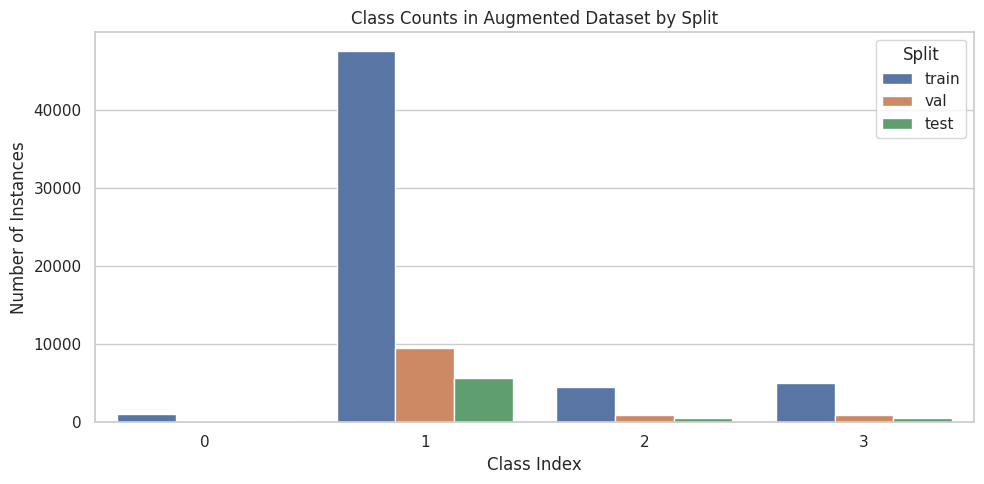

/tmp/ipykernel_57/809890121.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(split_totals.keys()), y=list(split_totals.values()), palette='viridis')


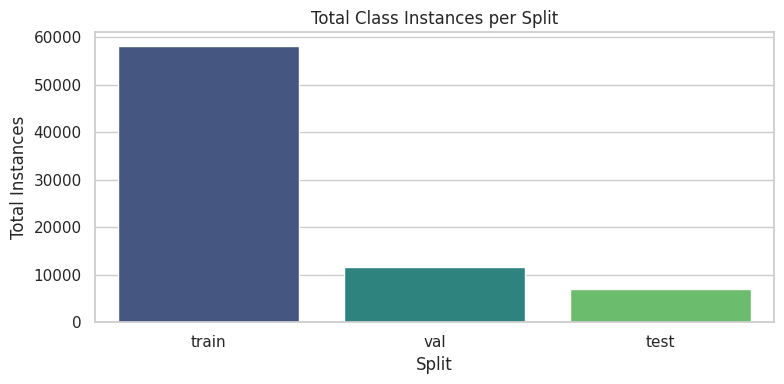

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

split_totals = {split: sum(counter.values()) for split, counter in class_counts.items()}
all_classes = sorted({cls for counter in class_counts.values() for cls in counter.keys()})

plot_rows = []
for split in ['train', 'val', 'test']:
    for cls in all_classes:
        plot_rows.append({'split': split, 'class': cls, 'count': class_counts[split].get(cls, 0)})

plot_df = pd.DataFrame(plot_rows)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x='class', y='count', hue='split')
plt.title('Class Counts in Augmented Dataset by Split')
plt.xlabel('Class Index')
plt.ylabel('Number of Instances')
plt.legend(title='Split')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(x=list(split_totals.keys()), y=list(split_totals.values()), palette='viridis')
plt.title('Total Class Instances per Split')
plt.xlabel('Split')
plt.ylabel('Total Instances')
plt.tight_layout()
plt.show()

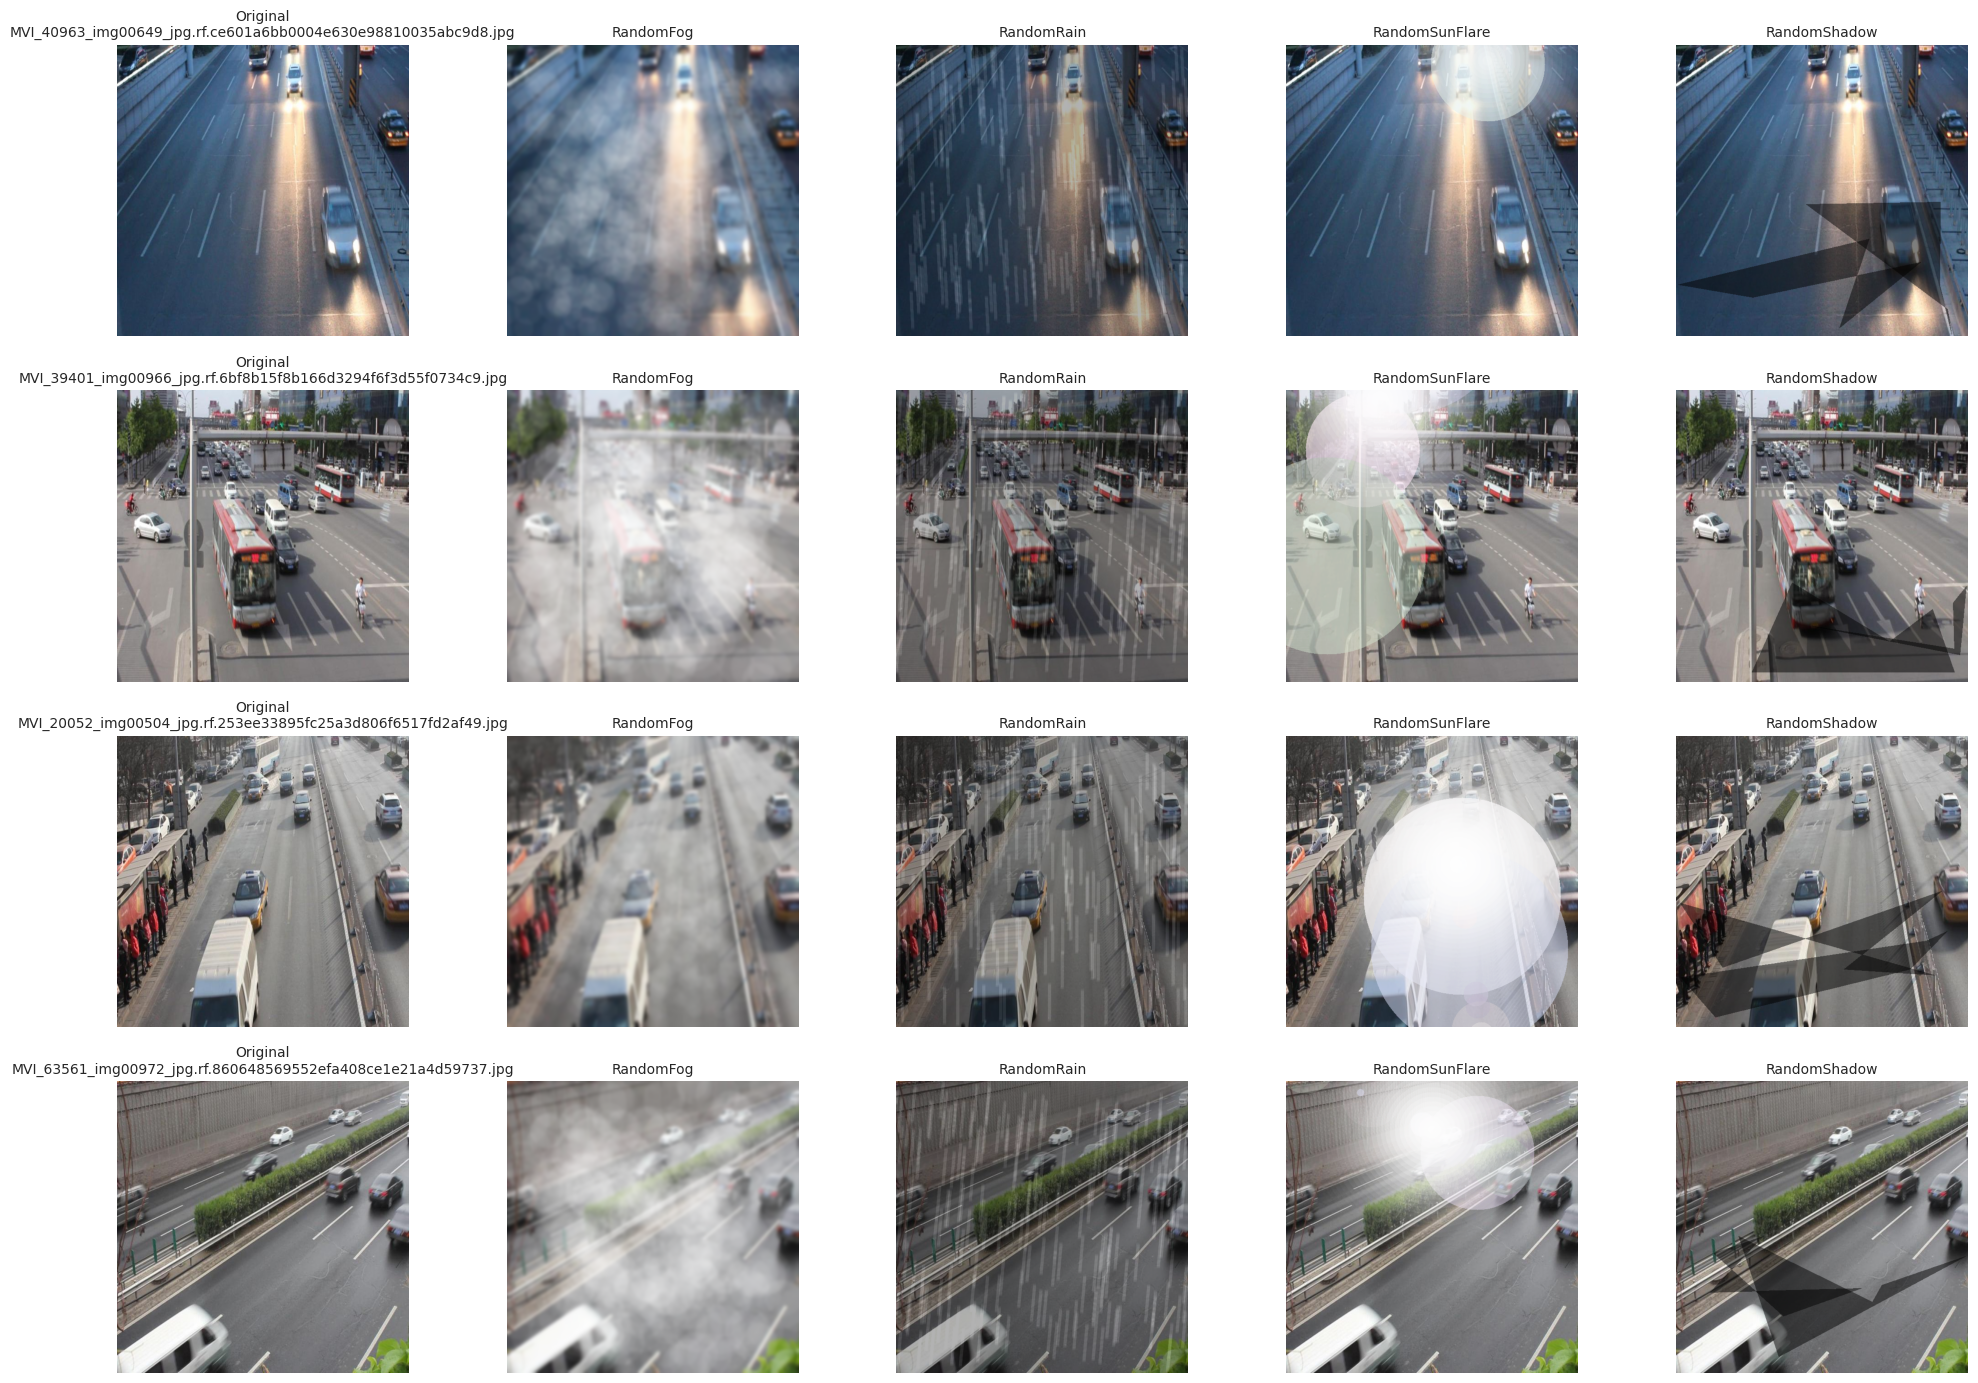

In [11]:
# Visualize RandomFog, RandomRain, RandomSunFlare, RandomShadow on random training images
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
import albumentations as A


seed_everything(SEED)
viz_rng = random.Random(SEED)

train_img_dir = Path('/kaggle/input/datasets/lishanthansa/3cl-mulitclass-vehicle-classification-augmented/augmentedDataset/test/images')
img_paths = sorted([p for p in train_img_dir.glob('*') if p.suffix.lower() in ('.jpg', '.jpeg', '.png')])

if len(img_paths) == 0:
    raise FileNotFoundError(f'No images found in: {train_img_dir.resolve()}')

num_samples = min(4, len(img_paths))
sampled_paths = viz_rng.sample(img_paths, num_samples)

# Build transforms with safe fallbacks in case a transform is unavailable.
fog_tfm = A.RandomFog(p=1.0) if hasattr(A, 'RandomFog') else A.NoOp(p=1.0)
rain_tfm = A.RandomRain(p=1.0)
sunflare_tfm = A.RandomSunFlare(p=1.0) if hasattr(A, 'RandomSunFlare') else A.NoOp(p=1.0)
shadow_tfm = A.RandomShadow(p=1.0) if hasattr(A, 'RandomShadow') else A.NoOp(p=1.0)

transform_specs = [
    ('Original', None),
    ('RandomFog', fog_tfm),
    ('RandomRain', rain_tfm),
    ('RandomSunFlare', sunflare_tfm),
    ('RandomShadow', shadow_tfm),
]

fig, axes = plt.subplots(num_samples, len(transform_specs), figsize=(4 * len(transform_specs), 3.5 * num_samples))
if num_samples == 1:
    axes = [axes]

for r, img_path in enumerate(sampled_paths):
    bgr = cv2.imread(str(img_path))
    if bgr is None:
        continue
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    for c, (title, tfm) in enumerate(transform_specs):
        ax = axes[r][c]
        if tfm is None:
            out = rgb
        else:
            # Reset seeds per panel so output stays stable even if loop logic changes.
            panel_seed = SEED + (r * 100) + c
            seed_everything(panel_seed)
            out = tfm(image=rgb)['image']

        ax.imshow(out)
        ax.set_title(title if c > 0 else f'Original\n{img_path.name}', fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.show()

Displaying 6 random train images with bounding boxes:


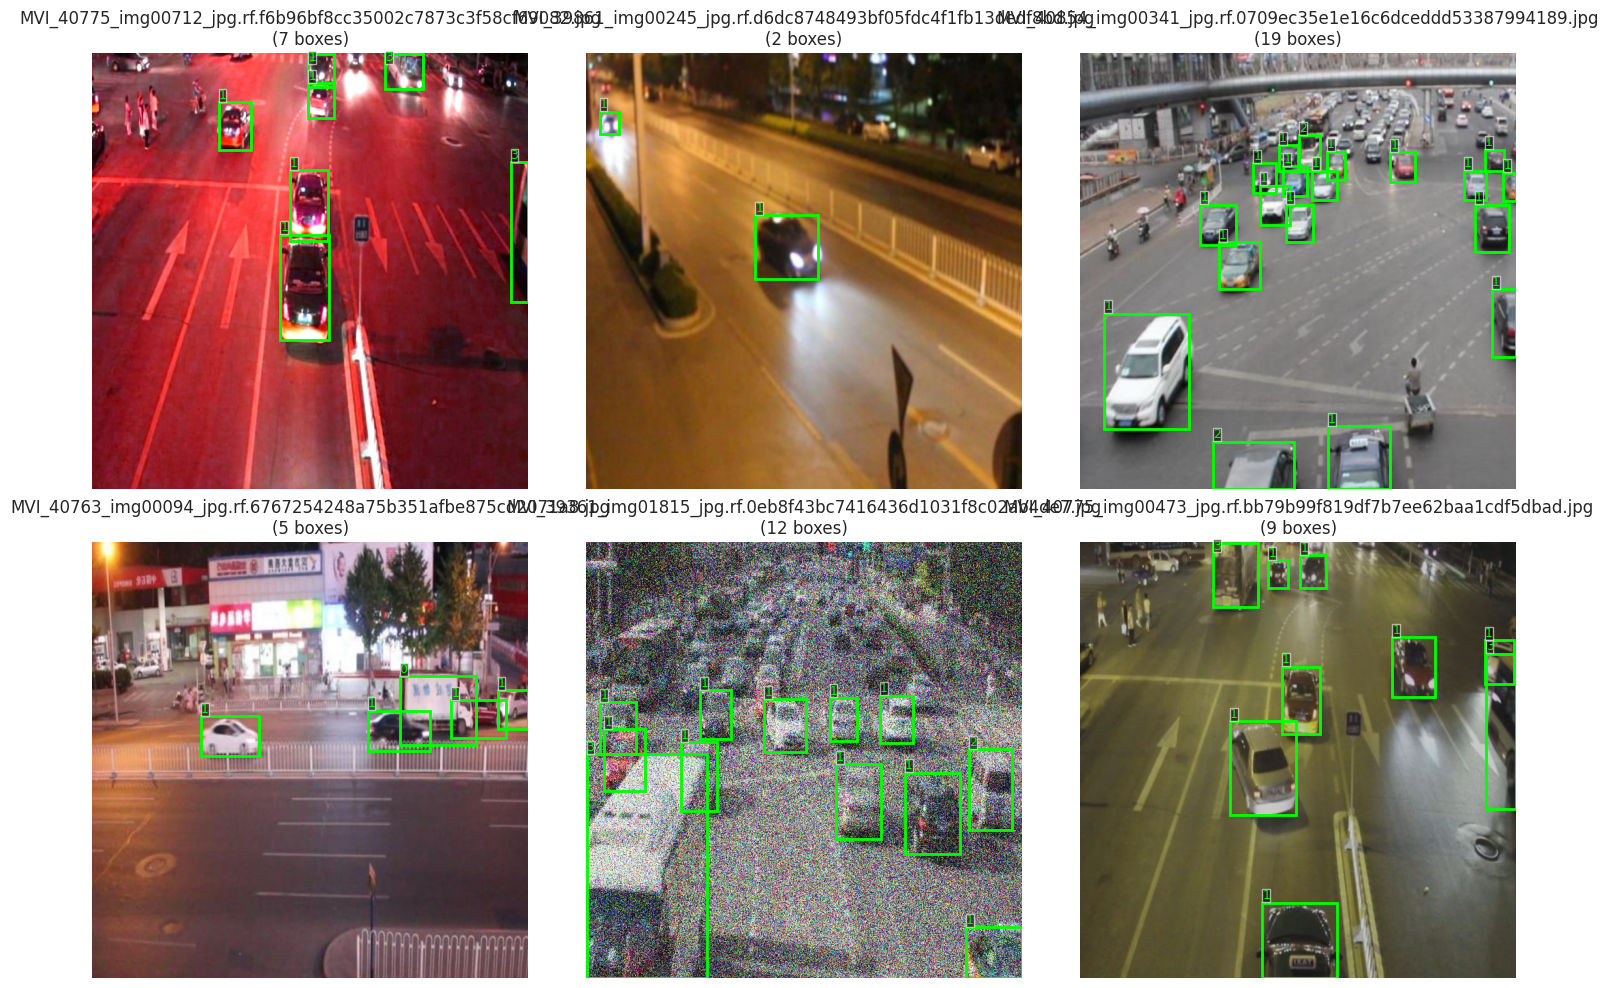

✓ Displayed 6 random training samples.


In [12]:
from matplotlib import patches

display_split = 'train'
train_images_dir = splits[display_split]
train_labels_dir = label_splits[display_split]

all_train_img_paths = sorted([p for p in train_images_dir.glob('*') if p.suffix.lower() in ('.jpg', '.jpeg', '.png')])
num_to_sample = min(6, len(all_train_img_paths))
train_img_paths = random.sample(all_train_img_paths, num_to_sample)

print(f'Displaying {len(train_img_paths)} random {display_split} images with bounding boxes:')

num_images = len(train_img_paths)
n_cols = 3
n_rows = (num_images + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() if num_images > 1 else [axes]

for idx, img_path in enumerate(train_img_paths):
    ax = axes[idx]
    img = cv2.imread(str(img_path))
    if img is None:
        ax.axis('off')
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    ax.imshow(img)

    bbox_count = 0
    label_path = train_labels_dir / (img_path.stem + '.txt')
    if label_path.exists():
        with open(label_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                try:
                    cls = int(float(parts[0]))
                    cx, cy, bw, bh = map(float, parts[1:5])
                    bbox_count += 1
                except Exception:
                    continue

                x1 = int((cx - bw / 2) * w)
                y1 = int((cy - bh / 2) * h)
                box_w = int(bw * w)
                box_h = int(bh * h)

                rect = patches.Rectangle((x1, y1), box_w, box_h, linewidth=2, edgecolor='lime', facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, max(y1 - 5, 10), f'{cls}', color='lime', fontsize=9, bbox=dict(facecolor='black', alpha=0.6, pad=0))
        ax.set_title(f'{img_path.name}\n({bbox_count} boxes)')
    else:
        ax.set_title(f'{img_path.name} (no labels)')

    ax.axis('off')

for idx in range(num_images, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(f'✓ Displayed {num_images} random training samples.')

## Phase 2 — Model Architecture


In [13]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.1 MB/s eta 0:00:00a 0:00:01


In [14]:
from ultralytics import YOLO

model = YOLO('yolo26m.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [15]:
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple

import os
import random

import numpy as np
import torch
import torch.nn as nn
import torchvision
from ultralytics import YOLO

PHASE2_CONFIG = {
    "project": {
        "name": "vehicle_detection_yolov26",
        "seed": 42,
    },
    "dataset": {
        "root": Path("./augmentedDatasetv2"),
        "train": "train",
        "val": "val",
        "test": "test",
        "nc": 4,
        "names": ["truck", "car", "van", "bus"],
        "img_size": 640,
    },
    "model": {
        "base": "yolo26m.pt",
        "num_classes": 4,
    },
    "training": {
        "epochs": 100,
        "batch_size": 16,
        "num_workers": 4,
        "img_size": 640,
        "lr_backbone": 1e-4,
        "lr_neck": 5e-4,
        "lr_heads": 1e-3,
        "lr_attention": 5e-4,
        "warmup_epochs": 3,
        "weight_decay": 0.05,
        "accumulation_steps": 4,
        "early_stopping_patience": 20,
        "amp": True,
    },
}

DATASET_ROOT = PHASE2_CONFIG["dataset"]["root"]
SEED = PHASE2_CONFIG["project"]["seed"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def seed_everything(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


seed_everything(SEED)

print(f"Phase 2 config ready on {DEVICE}.")
print(f"Dataset root: {DATASET_ROOT.resolve()}")

Phase 2 config ready on cuda.
Dataset root: /kaggle/working/augmentedDatasetv2


In [16]:
## Sanity check dataset structure before creating datasets/loaders
# from torch.utils.data import DataLoader


# DATASET_ROOT = PHASE2_CONFIG["dataset"]["root"] if "PHASE2_CONFIG" in globals() else Path("augmentedDatasetv2")
# SPLIT_DIRS = {
#     split: {
#         "images": DATASET_ROOT / split / "images",
#         "labels": DATASET_ROOT / split / "labels",
#     }
#     for split in ("train", "val", "test")
# }

# for split, split_dirs in SPLIT_DIRS.items():
#     if not split_dirs["images"].exists():
#         raise FileNotFoundError(f"Missing images directory for {split}: {split_dirs['images']}")
#     if not split_dirs["labels"].exists():
#         raise FileNotFoundError(f"Missing labels directory for {split}: {split_dirs['labels']}")


# def vehicle_collate_fn(batch):
#     images = torch.stack([item[0] for item in batch], dim=0)
#     targets = [item[1] for item in batch]
#     return {"images": images, "targets": targets}


# train_dataset = VehicleDataset(
#     image_dir=SPLIT_DIRS["train"]["images"],
#     label_dir=SPLIT_DIRS["train"]["labels"],
#     img_size=PHASE2_CONFIG["dataset"]["img_size"],
#     transforms=train_transforms,
#     mode="train",
#     mosaic_prob=0.5,
# )
# val_dataset = VehicleDataset(
#     image_dir=SPLIT_DIRS["val"]["images"],
#     label_dir=SPLIT_DIRS["val"]["labels"],
#     img_size=PHASE2_CONFIG["dataset"]["img_size"],
#     transforms=val_transforms,
#     mode="val",
#     mosaic_prob=0.0,
# )
# test_dataset = VehicleDataset(
#     image_dir=SPLIT_DIRS["test"]["images"],
#     label_dir=SPLIT_DIRS["test"]["labels"],
#     img_size=PHASE2_CONFIG["dataset"]["img_size"],
#     transforms=val_transforms,
#     mode="test",
#     mosaic_prob=0.0,
# )

# loader_workers = 0

# train_loader = DataLoader(
#     train_dataset,
#     batch_size=PHASE2_CONFIG["training"]["batch_size"],
#     shuffle=True,
#     num_workers=loader_workers,
#     pin_memory=torch.cuda.is_available(),
#     collate_fn=vehicle_collate_fn,
# )
# val_loader = DataLoader(
#     val_dataset,
#     batch_size=PHASE2_CONFIG["training"]["batch_size"],
#     shuffle=False,
#     num_workers=loader_workers,
#     pin_memory=torch.cuda.is_available(),
#     collate_fn=vehicle_collate_fn,
# )
# test_loader = DataLoader(
#     test_dataset,
#     batch_size=PHASE2_CONFIG["training"]["batch_size"],
#     shuffle=False,
#     num_workers=loader_workers,
#     pin_memory=torch.cuda.is_available(),
#     collate_fn=vehicle_collate_fn,
# )

# sample_batch = next(iter(train_loader))
# print("Dataset root:", DATASET_ROOT.resolve())
# print("Train/Val/Test sizes:", len(train_dataset), len(val_dataset), len(test_dataset))
# print("Sample batch image shape:", tuple(sample_batch["images"].shape))
# print("Sample batch target count:", len(sample_batch["targets"]))

In [17]:
class DeformableConv2d(nn.Module):
    """Drop-in replacement for nn.Conv2d with kernel_size=3.

    Uses torchvision.ops.deform_conv2d internally and starts from a stable
    initialization where offsets are zero and modulation begins at full weight.
    """

    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.kernel_size = kernel_size
        self.offset_conv = nn.Conv2d(
            in_channels,
            2 * kernel_size * kernel_size,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
        )
        self.modulator_conv = nn.Conv2d(
            in_channels,
            kernel_size * kernel_size,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
        )
        self.main_conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            bias=False,
        )

        nn.init.zeros_(self.offset_conv.weight)
        if self.offset_conv.bias is not None:
            nn.init.zeros_(self.offset_conv.bias)
        nn.init.zeros_(self.modulator_conv.weight)
        if self.modulator_conv.bias is not None:
            nn.init.ones_(self.modulator_conv.bias)

    def forward(self, x):
        offset = self.offset_conv(x)
        modulator = torch.sigmoid(self.modulator_conv(x))
        return torchvision.ops.deform_conv2d(
            x,
            offset,
            self.main_conv.weight,
            mask=modulator,
            bias=self.main_conv.bias,
            stride=self.main_conv.stride,
            padding=self.main_conv.padding,
        )

In [18]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        mid = max(1, channels // reduction)
        self.mlp = nn.Sequential(
            nn.Linear(channels, mid),
            nn.ReLU(inplace=True),
            nn.Linear(mid, channels),
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        avg = torch.nn.functional.adaptive_avg_pool2d(x, 1).view(b, c)
        mx = torch.nn.functional.adaptive_max_pool2d(x, 1).view(b, c)
        scale = torch.sigmoid(self.mlp(avg) + self.mlp(mx)).view(b, c, 1, 1)
        return x * scale


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = (kernel_size - 1) // 2
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx = torch.max(x, dim=1, keepdim=True)[0]
        attn = torch.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))
        return x * attn


class FrequencyAttention(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        mid = max(1, channels // reduction)
        self.mlp = nn.Sequential(
            nn.Linear(channels, mid),
            nn.ReLU(inplace=True),
            nn.Linear(mid, channels),
        )

    def forward(self, x):
        b, c, h, w = x.shape
        freq = torch.fft.fft2(x, dim=(-2, -1), norm="ortho")
        descriptor = torch.abs(freq).mean(dim=(-2, -1))
        weights = torch.sigmoid(self.mlp(descriptor)).view(b, c, 1, 1)
        refined = torch.fft.ifft2(freq * weights, dim=(-2, -1), norm="ortho").real
        return x + refined


class DualDomainAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.channel_att = ChannelAttention(channels)
        self.spatial_att = SpatialAttention(kernel_size=7)
        self.freq_att = FrequencyAttention(channels)
        self.fusion = nn.Conv2d(2 * channels, channels, kernel_size=1, bias=False)

    def forward(self, x):
        spatial_out = self.spatial_att(self.channel_att(x))
        freq_out = self.freq_att(x)
        return self.fusion(torch.cat([spatial_out, freq_out], dim=1))

In [19]:
def load_backbone(weights_path="yolo26m.pt"):
    """Load YOLOv26 weights and return the backbone module plus full model."""
    model = YOLO(weights_path)
    full_model = getattr(model, "model", None)
    if full_model is None:
        raise RuntimeError("Could not find model.model in the Ultralytics YOLO object.")

    backbone_module = getattr(full_model, "backbone", full_model)
    for parameter in backbone_module.parameters():
        parameter.requires_grad = False

    return backbone_module, model


class DualDomainPyramidRefiner(nn.Module):
    def __init__(self, channels=(256, 512, 1024)):
        super().__init__()
        self.p3 = DualDomainAttention(channels[0])
        self.p4 = DualDomainAttention(channels[1])
        self.p5 = DualDomainAttention(channels[2])

    def forward(self, features):
        p3, p4, p5 = features
        return self.p3(p3), self.p4(p4), self.p5(p5)


phase2_backbone, phase2_model = load_backbone(PHASE2_CONFIG["model"]["base"])
phase2_refiner = DualDomainPyramidRefiner().to(DEVICE)

with torch.no_grad():
    dummy_features = (
        torch.randn(1, 256, 80, 80, device=DEVICE),
        torch.randn(1, 512, 40, 40, device=DEVICE),
        torch.randn(1, 1024, 20, 20, device=DEVICE),
    )
    refined_features = phase2_refiner(dummy_features)

print("Backbone frozen:", all(not p.requires_grad for p in phase2_backbone.parameters()))
print("Refined feature shapes:", [tuple(feature.shape) for feature in refined_features])

Backbone frozen: True
Refined feature shapes: [(1, 256, 80, 80), (1, 512, 40, 40), (1, 1024, 20, 20)]


## Phase 2.4 — Modified Neck and Detector Assembly

In [20]:
import torch.nn.functional as F


class ConvBNAct(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=1, stride=1, padding=0):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            bias=False,
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.act = nn.SiLU(inplace=True)

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))


class DeformableConvBNAct(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.deform = DeformableConv2d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.act = nn.SiLU(inplace=True)

    def forward(self, x):
        return self.act(self.bn(self.deform(x)))


class ModifiedNeck(nn.Module):
    """FPN + PAN neck with deformable 3x3 fusion blocks at merge points."""

    def __init__(self):
        super().__init__()
        self.p5_reduce = ConvBNAct(1024, 512, kernel_size=1, stride=1, padding=0)
        self.fpn_p4_fuse = DeformableConvBNAct(1024, 512, kernel_size=3, stride=1, padding=1)
        self.fpn_p4_reduce = ConvBNAct(512, 256, kernel_size=1, stride=1, padding=0)
        self.n3_fuse = DeformableConvBNAct(512, 256, kernel_size=3, stride=1, padding=1)
        self.down_n3 = ConvBNAct(256, 256, kernel_size=3, stride=2, padding=1)
        self.n4_fuse = DeformableConvBNAct(768, 512, kernel_size=3, stride=1, padding=1)
        self.down_n4 = ConvBNAct(512, 512, kernel_size=3, stride=2, padding=1)
        self.n5_fuse = ConvBNAct(1536, 1024, kernel_size=3, stride=1, padding=1)

    def forward(self, p3, p4, p5):
        p5_td = self.p5_reduce(p5)
        p5_up = F.interpolate(p5_td, size=p4.shape[-2:], mode="nearest")
        fpn_p4 = self.fpn_p4_fuse(torch.cat([p5_up, p4], dim=1))

        fpn_p4_td = self.fpn_p4_reduce(fpn_p4)
        fpn_p4_up = F.interpolate(fpn_p4_td, size=p3.shape[-2:], mode="nearest")
        n3 = self.n3_fuse(torch.cat([fpn_p4_up, p3], dim=1))

        n3_down = self.down_n3(n3)
        n4 = self.n4_fuse(torch.cat([n3_down, fpn_p4], dim=1))

        n4_down = self.down_n4(n4)
        n5 = self.n5_fuse(torch.cat([n4_down, p5], dim=1))
        return n3, n4, n5


class DualDomainAttentionBridge(nn.Module):
    """Applies separate DDA weights at the three pyramid scales."""

    def __init__(self):
        super().__init__()
        self.dda_small = DualDomainAttention(256)
        self.dda_medium = DualDomainAttention(512)
        self.dda_large = DualDomainAttention(1024)

    def forward(self, n3, n4, n5):
        return (
            self.dda_small(n3),
            self.dda_medium(n4),
            self.dda_large(n5),
        )

In [21]:
def _cfg_value(config, *keys, default=None):
    value = config
    for key in keys:
        if isinstance(value, dict):
            value = value.get(key, default)
        else:
            value = getattr(value, key, default)
        if value is default:
            return default
    return value


class VehicleDetectorYOLOv26(nn.Module):
    """Assembles the YOLOv26 backbone, modified neck, DDA bridge, and heads."""

    def __init__(self, config):
        super().__init__()
        self.config = config
        weights_path = _cfg_value(config, "model", "base", default="yolo26m.pt")
        self.num_classes = _cfg_value(config, "model", "num_classes", default=_cfg_value(config, "dataset", "nc", default=80))
        self.yolo = YOLO(weights_path)
        self.base_model = self.yolo.model

        self.backbone = getattr(self.base_model, "backbone", self.base_model)
        for parameter in self.backbone.parameters():
            parameter.requires_grad = False

        raw_layers = list(getattr(self.base_model, "model", []))
        self.backbone_layers = nn.ModuleList(raw_layers[:10])
        self.original_neck_layers = nn.ModuleList(raw_layers[10:22])
        self.heads = nn.Sequential(*raw_layers[22:]) if len(raw_layers[22:]) > 0 else nn.Identity()

        self.neck = ModifiedNeck()
        self.dda_small = DualDomainAttention(256)
        self.dda_medium = DualDomainAttention(512)
        self.dda_large = DualDomainAttention(1024)

        self.classifier_rebuild_needed = self.num_classes != 80

    def forward(self, x):
        """This notebook implementation expects backbone features p3, p4, p5."""
        if not isinstance(x, (tuple, list)) or len(x) != 3:
            raise ValueError(
                "VehicleDetectorYOLOv26.forward expects (p3, p4, p5) feature maps in this notebook implementation."
            )

        p3, p4, p5 = x
        n3, n4, n5 = self.neck(p3, p4, p5)
        a3 = self.dda_small(n3)
        a4 = self.dda_medium(n4)
        a5 = self.dda_large(n5)

        if isinstance(self.heads, nn.Identity):
            return a3, a4, a5
        return self.heads([a3, a4, a5])

    def get_parameter_groups(self, config):
        """Return optimizer groups with per-module learning rates."""
        return [
            {
                "params": self.backbone_layers.parameters(),
                "lr": _cfg_value(config, "training", "lr_backbone", default=1e-4),
            },
            {
                "params": self.neck.parameters(),
                "lr": _cfg_value(config, "training", "lr_neck", default=5e-4),
            },
            {
                "params": [
                    *self.dda_small.parameters(),
                    *self.dda_medium.parameters(),
                    *self.dda_large.parameters(),
                ],
                "lr": _cfg_value(config, "training", "lr_attention", default=5e-4),
            },
            {
                "params": self.heads.parameters(),
                "lr": _cfg_value(config, "training", "lr_heads", default=1e-3),
            },
        ]


phase2_detector = VehicleDetectorYOLOv26(PHASE2_CONFIG).to(DEVICE)
print("Modified neck ready:", phase2_detector.neck.__class__.__name__)
print("Attention bridge ready:", phase2_detector.dda_small.__class__.__name__, phase2_detector.dda_medium.__class__.__name__, phase2_detector.dda_large.__class__.__name__)
print("Head rebuild needed:", phase2_detector.classifier_rebuild_needed)

Modified neck ready: ModifiedNeck
Attention bridge ready: DualDomainAttention DualDomainAttention DualDomainAttention
Head rebuild needed: True


In [22]:
with torch.no_grad():
    dummy_p3 = torch.randn(1, 256, 80, 80, device=DEVICE)
    dummy_p4 = torch.randn(1, 512, 40, 40, device=DEVICE)
    dummy_p5 = torch.randn(1, 1024, 20, 20, device=DEVICE)
    neck_outs = phase2_detector.neck(dummy_p3, dummy_p4, dummy_p5)
    bridge_outs = (
        phase2_detector.dda_small(neck_outs[0]),
        phase2_detector.dda_medium(neck_outs[1]),
        phase2_detector.dda_large(neck_outs[2]),
    )

print("Neck output shapes:", [tuple(t.shape) for t in neck_outs])
print("Bridge output shapes:", [tuple(t.shape) for t in bridge_outs])

Neck output shapes: [(1, 256, 80, 80), (1, 512, 40, 40), (1, 1024, 20, 20)]
Bridge output shapes: [(1, 256, 80, 80), (1, 512, 40, 40), (1, 1024, 20, 20)]


## Phase 3 — Loss Function

In [23]:
class VehicleDetectionLoss(nn.Module):
    """YOLO-style loss with CIoU box loss, Varifocal classification loss, and DFL."""

    def __init__(self, reg_max=16, box_weight=7.5, cls_weight=0.5, dfl_weight=1.5, class_weights=None):
        super().__init__()
        self.reg_max = reg_max
        self.box_weight = box_weight
        self.cls_weight = cls_weight
        self.dfl_weight = dfl_weight
        self.class_weights = None if class_weights is None else torch.as_tensor(class_weights, dtype=torch.float32)
        self.project = torch.arange(reg_max + 1, dtype=torch.float32)

    @staticmethod
    def _xywh_to_xyxy(boxes):
        cx, cy, w, h = boxes.unbind(-1)
        half_w = w / 2
        half_h = h / 2
        return torch.stack((cx - half_w, cy - half_h, cx + half_w, cy + half_h), dim=-1)

    @staticmethod
    def _bbox_area(boxes):
        return (boxes[..., 2] - boxes[..., 0]).clamp(min=0) * (boxes[..., 3] - boxes[..., 1]).clamp(min=0)

    def ciou_loss(self, pred_boxes, target_boxes, eps=1e-7):
        pred_xyxy = self._xywh_to_xyxy(pred_boxes)
        target_xyxy = self._xywh_to_xyxy(target_boxes)

        inter_x1 = torch.maximum(pred_xyxy[..., 0], target_xyxy[..., 0])
        inter_y1 = torch.maximum(pred_xyxy[..., 1], target_xyxy[..., 1])
        inter_x2 = torch.minimum(pred_xyxy[..., 2], target_xyxy[..., 2])
        inter_y2 = torch.minimum(pred_xyxy[..., 3], target_xyxy[..., 3])
        inter_w = (inter_x2 - inter_x1).clamp(min=0)
        inter_h = (inter_y2 - inter_y1).clamp(min=0)
        inter_area = inter_w * inter_h

        pred_area = self._bbox_area(pred_xyxy)
        target_area = self._bbox_area(target_xyxy)
        union = pred_area + target_area - inter_area + eps
        iou = inter_area / union

        pred_center = pred_boxes[..., :2]
        target_center = target_boxes[..., :2]
        center_dist = ((pred_center - target_center) ** 2).sum(dim=-1)

        enc_x1 = torch.minimum(pred_xyxy[..., 0], target_xyxy[..., 0])
        enc_y1 = torch.minimum(pred_xyxy[..., 1], target_xyxy[..., 1])
        enc_x2 = torch.maximum(pred_xyxy[..., 2], target_xyxy[..., 2])
        enc_y2 = torch.maximum(pred_xyxy[..., 3], target_xyxy[..., 3])
        enc_diag = ((enc_x2 - enc_x1) ** 2 + (enc_y2 - enc_y1) ** 2).clamp(min=eps)

        pred_w = (pred_boxes[..., 2]).clamp(min=eps)
        pred_h = (pred_boxes[..., 3]).clamp(min=eps)
        target_w = (target_boxes[..., 2]).clamp(min=eps)
        target_h = (target_boxes[..., 3]).clamp(min=eps)
        v = (4 / torch.pi**2) * torch.pow(torch.atan(target_w / target_h) - torch.atan(pred_w / pred_h), 2)
        alpha = v / (1 - iou + v + eps)
        ciou = iou - (center_dist / enc_diag + alpha * v)
        return 1 - ciou

    def varifocal_loss(self, pred_logits, target_scores, target_labels=None, alpha=0.75, gamma=2.0):
        pred_prob = torch.sigmoid(pred_logits)
        pos_loss = target_scores * torch.log(pred_prob.clamp(min=1e-7))
        neg_loss = (1 - target_scores) * (pred_prob ** gamma) * torch.log((1 - pred_prob).clamp(min=1e-7))
        loss = -(alpha * pos_loss + neg_loss)

        if target_labels is not None and self.class_weights is not None:
            weights = self.class_weights.to(pred_logits.device)[target_labels]
            loss = loss * weights.unsqueeze(-1)
        return loss.mean()

    def dfl_loss(self, pred_dist, target_dist):
        target_dist = target_dist.clamp(min=0, max=self.reg_max - 1 - 1e-4)
        left = target_dist.floor().long()
        right = (left + 1).clamp(max=self.reg_max)
        weight_right = target_dist - left.float()
        weight_left = 1 - weight_right
        log_prob = torch.log_softmax(pred_dist, dim=-1)
        left_loss = F.nll_loss(log_prob.view(-1, log_prob.size(-1)), left.view(-1), reduction="none")
        right_loss = F.nll_loss(log_prob.view(-1, log_prob.size(-1)), right.view(-1), reduction="none")
        return (weight_left.view(-1) * left_loss + weight_right.view(-1) * right_loss).mean()

    def forward(self, preds, targets):
        """Compute losses from a TAL-style assignment dict or a compatible target batch.

        Expected keys in `preds`:
          boxes: [N, 4] predicted xywh boxes for positives
          logits: [N, C] class logits for positives
          dfl:    [N, 4, reg_max + 1] distribution logits for each box edge
          iou_targets: [N] quality targets from TAL
          labels: [N] class indices for positives
          negatives_logits: [M, C] logits for negatives, optional
          assigned_boxes: [N, 4] ground-truth xywh boxes, optional
          reg_targets: [N, 4] continuous box-edge targets for DFL, optional
        """
        pred_boxes = preds["boxes"]
        pred_logits = preds["logits"]
        pred_dfl = preds["dfl"]
        iou_targets = preds.get("iou_targets", torch.ones(pred_boxes.size(0), device=pred_boxes.device))
        labels = preds.get("labels", torch.zeros(pred_boxes.size(0), dtype=torch.long, device=pred_boxes.device))
        assigned_boxes = preds.get("assigned_boxes", pred_boxes.detach())
        reg_targets = preds.get("reg_targets", torch.zeros_like(pred_dfl[..., 0]))
        negatives_logits = preds.get("negatives_logits")

        box_loss = self.ciou_loss(pred_boxes, assigned_boxes).mean() if pred_boxes.numel() else pred_boxes.sum() * 0.0
        cls_target = F.one_hot(labels, num_classes=pred_logits.size(-1)).to(pred_logits.dtype) * iou_targets.unsqueeze(-1)
        cls_loss = self.varifocal_loss(pred_logits, cls_target, labels if self.class_weights is not None else None)
        dfl_loss = self.dfl_loss(pred_dfl, reg_targets) if pred_dfl.numel() else pred_dfl.sum() * 0.0

        if negatives_logits is not None and negatives_logits.numel():
            negative_targets = torch.zeros_like(negatives_logits)
            cls_loss = cls_loss + F.binary_cross_entropy_with_logits(negatives_logits, negative_targets)

        total = self.box_weight * box_loss + self.cls_weight * cls_loss + self.dfl_weight * dfl_loss
        return {
            "loss": total,
            "box_loss": box_loss,
            "cls_loss": cls_loss,
            "dfl_loss": dfl_loss,
        }


phase3_loss = VehicleDetectionLoss(class_weights=[1.2, 1.0, 1.3, 1.4])
print("VehicleDetectionLoss ready with reg_max =", phase3_loss.reg_max)

VehicleDetectionLoss ready with reg_max = 16


In [25]:
with torch.no_grad():
    synthetic_preds = {
        "boxes": torch.tensor(
            [
                [0.50, 0.50, 0.20, 0.30],
                [0.35, 0.45, 0.15, 0.20],
            ],
            dtype=torch.float32,
        ),
        "logits": torch.randn(2, 4),
        "dfl": torch.randn(2, 4, phase3_loss.reg_max + 1),
        "iou_targets": torch.tensor([0.82, 0.63], dtype=torch.float32),
        "labels": torch.tensor([1, 3], dtype=torch.long),
        "assigned_boxes": torch.tensor(
            [
                [0.52, 0.48, 0.18, 0.28],
                [0.33, 0.44, 0.16, 0.22],
            ],
            dtype=torch.float32,
        ),
        "reg_targets": torch.tensor(
            [
                [2.3, 3.7, 1.2, 4.6],
                [1.5, 2.1, 3.4, 5.2],
            ],
            dtype=torch.float32,
        ),
        "negatives_logits": torch.randn(3, 4),
    }
    synthetic_targets = {}
    synthetic_loss = phase3_loss(synthetic_preds, synthetic_targets)

print({key: float(value.detach().cpu()) for key, value in synthetic_loss.items()})

{'loss': 8.260775566101074, 'box_loss': 0.2968009114265442, 'cls_loss': 1.102088212966919, 'dfl_loss': 3.6558165550231934}


## Phase 4 — Training Loop

In [28]:
from contextlib import contextmanager
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Optional, Tuple

import torch
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter


try:
    import kornia.augmentation as K
except Exception:
    K = None


class ModelEMA:
    """Exponential moving average of model weights stored as a shadow state dict."""

    def __init__(self, model, decay=0.9999):
        self.decay = decay
        self.shadow = {
            key: value.detach().clone().cpu()
            for key, value in model.state_dict().items()
        }

    def update(self, model):
        with torch.no_grad():
            model_state = model.state_dict()
            for key, shadow_value in self.shadow.items():
                model_value = model_state[key].detach().cpu()
                if torch.is_floating_point(shadow_value):
                    shadow_value.mul_(self.decay).add_(model_value, alpha=1.0 - self.decay)
                else:
                    shadow_value.copy_(model_value)

    def state_dict(self):
        return {key: value.clone() for key, value in self.shadow.items()}

    def load_state_dict(self, state_dict):
        self.shadow = {key: value.detach().clone().cpu() for key, value in state_dict.items()}


class SimpleGPUAugmenter(nn.Module):
    """Optional GPU-side image augmentation for training batches."""

    def __init__(self):
        super().__init__()
        self.hflip = K.RandomHorizontalFlip(p=0.5) if K is not None else None
        self.jitter = (
            K.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02, p=0.4)
            if K is not None
            else None
        )

    def forward(self, images):
        if self.hflip is not None:
            images = self.hflip(images)
        if self.jitter is not None:
            images = self.jitter(images)
        return images


@dataclass
class TrainerState:
    epoch: int = 0
    best_map50: float = 0.0
    best_epoch: int = -1
    stale_epochs: int = 0
    global_step: int = 0


class Trainer:
    """
    Training loop for VehicleDetectorYOLOv26 with EMA, accumulation,
    validation hooks, checkpointing, and early stopping.
    """

    def __init__(self, model, criterion, config, device=None, log_dir=None, evaluator=None, forward_fn=None):
        self.model = model
        self.criterion = criterion
        self.config = config
        self.device = device or DEVICE
        self.evaluator = evaluator
        self.forward_fn = forward_fn
        self.state = TrainerState()
        self.log_dir = Path(log_dir or "runs/vehicle_detection_yolov26")
        self.log_dir.mkdir(parents=True, exist_ok=True)
        self.writer = SummaryWriter(log_dir=str(self.log_dir))
        self.scaler = torch.amp.GradScaler("cuda", enabled=self.device.type == "cuda")
        self.augmenter = SimpleGPUAugmenter().to(self.device)
        self.ema = ModelEMA(self.model, decay=0.9999)
        self._freeze_backbone_if_needed(0)

    def _training_cfg(self, key, default=None):
        training = self.config.get("training", {}) if isinstance(self.config, dict) else getattr(self.config, "training", {})
        if isinstance(training, dict):
            return training.get(key, default)
        return getattr(training, key, default)

    def _freeze_backbone_if_needed(self, epoch):
        freeze_until = 10
        if hasattr(self.model, "backbone"):
            for parameter in self.model.backbone.parameters():
                parameter.requires_grad = epoch < freeze_until
            if epoch == freeze_until:
                for parameter in self.model.backbone.parameters():
                    parameter.requires_grad = True

    def _build_optimizer(self):
        return torch.optim.AdamW(
            self.model.get_parameter_groups(self.config),
            weight_decay=self._training_cfg("weight_decay", 0.05),
        )

    def _build_scheduler(self, optimizer, steps_per_epoch):
        max_lr = [
            self._training_cfg("lr_backbone", 1e-4),
            self._training_cfg("lr_neck", 5e-4),
            self._training_cfg("lr_attention", 5e-4),
            self._training_cfg("lr_heads", 1e-3),
        ]
        return torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=max_lr,
            epochs=self._training_cfg("epochs", 100),
            steps_per_epoch=max(1, steps_per_epoch),
            pct_start=0.1,
            anneal_strategy="cos",
        )

    def _unpack_batch(self, batch):
        if isinstance(batch, dict):
            images = batch.get("images")
            if images is None:
                images = batch.get("img")
            if images is None:
                images = batch.get("inputs")
            targets = batch.get("targets")
            if targets is None:
                targets = batch.get("labels")
            if targets is None:
                targets = {k: v for k, v in batch.items() if k not in {"images", "img", "inputs"}}
            return images, targets
        if isinstance(batch, (tuple, list)):
            if len(batch) == 0:
                raise ValueError("Empty batch received from the dataloader.")
            images = batch[0]
            targets = batch[1] if len(batch) > 1 else {}
            return images, targets
        raise TypeError(f"Unsupported batch type: {type(batch).__name__}")

    def _move_targets(self, targets):
        if isinstance(targets, dict):
            return {
                key: value.to(self.device) if torch.is_tensor(value) else value
                for key, value in targets.items()
            }
        if torch.is_tensor(targets):
            return targets.to(self.device)
        return targets

    def _augment_images(self, images):
        if images.is_cuda:
            return self.augmenter(images)
        return images

    def _forward_model(self, images, targets=None):
        if self.forward_fn is not None:
            return self.forward_fn(self.model, images, targets)
        if hasattr(self.model, "forward_train"):
            return self.model.forward_train(images, targets)
        return self.model(images), targets

    def _compute_loss(self, preds, targets):
        if isinstance(preds, dict) and isinstance(targets, dict):
            return self.criterion(preds, targets)
        if isinstance(preds, (tuple, list)) and isinstance(targets, dict):
            return self.criterion({"boxes": preds[0], "logits": preds[1], "dfl": preds[2]}, targets)
        return self.criterion(preds, targets)

    def _log_step(self, loss_dict, optimizer, step):
        if step % 50 != 0:
            return
        lr = optimizer.param_groups[0]["lr"]
        self.writer.add_scalar("train/total_loss", float(loss_dict["loss"].detach().cpu()), self.state.global_step)
        self.writer.add_scalar("train/box_loss", float(loss_dict["box_loss"].detach().cpu()), self.state.global_step)
        self.writer.add_scalar("train/cls_loss", float(loss_dict["cls_loss"].detach().cpu()), self.state.global_step)
        self.writer.add_scalar("train/dfl_loss", float(loss_dict["dfl_loss"].detach().cpu()), self.state.global_step)
        self.writer.add_scalar("train/lr", lr, self.state.global_step)

    @contextmanager
    def _ema_context(self):
        backup = {key: value.detach().clone() for key, value in self.model.state_dict().items()}
        self.model.load_state_dict(self.ema.state_dict(), strict=False)
        try:
            yield
        finally:
            self.model.load_state_dict(backup, strict=False)

    def train_one_epoch(self, train_loader, optimizer, scheduler):
        self.model.train()
        self._freeze_backbone_if_needed(self.state.epoch)
        optimizer.zero_grad(set_to_none=True)
        accumulation_steps = self._training_cfg("accumulation_steps", 4)
        total_loss = 0.0

        for step, batch in enumerate(train_loader):
            images, targets = self._unpack_batch(batch)
            images = images.to(self.device, non_blocking=True)
            targets = self._move_targets(targets)
            images = self._augment_images(images)

            with torch.autocast(device_type=self.device.type, enabled=self.device.type == "cuda"):
                preds, unpacked_targets = self._forward_model(images, targets)
                loss_dict = self._compute_loss(preds, unpacked_targets)
                loss = loss_dict["loss"] / accumulation_steps

            self.scaler.scale(loss).backward()
            total_loss += float(loss_dict["loss"].detach().cpu())

            if (step + 1) % accumulation_steps == 0:
                self.scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=10.0)
                self.scaler.step(optimizer)
                self.scaler.update()
                optimizer.zero_grad(set_to_none=True)
                self.ema.update(self.model)
                scheduler.step()

            self._log_step(loss_dict, optimizer, step)
            self.state.global_step += 1

        return total_loss / max(1, len(train_loader))

    @torch.no_grad()
    def validate(self, val_loader):
        self.model.eval()
        total_loss = 0.0
        metric_output = {"map50": 0.0, "map5095": 0.0, "per_class_ap": {}}

        with self._ema_context():
            self.model.eval()
            for batch in val_loader:
                images, targets = self._unpack_batch(batch)
                images = images.to(self.device, non_blocking=True)
                targets = self._move_targets(targets)
                with torch.autocast(device_type=self.device.type, enabled=self.device.type == "cuda"):
                    preds, unpacked_targets = self._forward_model(images, targets)
                    loss_dict = self._compute_loss(preds, unpacked_targets)
                total_loss += float(loss_dict["loss"].detach().cpu())

            if self.evaluator is not None:
                metric_output = self.evaluator(self.model, val_loader, self.device)

        if self.device.type == "cuda":
            torch.cuda.empty_cache()
        metric_output["val_loss"] = total_loss / max(1, len(val_loader))
        return metric_output

    def _save_checkpoint(self, path, optimizer, epoch, metrics, config, class_names):
        checkpoint = {
            "model": self.model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "ema": self.ema.state_dict(),
            "epoch": epoch,
            "metrics": metrics,
            "config": config,
            "class_names": class_names,
        }
        torch.save(checkpoint, path)

    def fit(self, train_loader, val_loader, class_names=None):
        optimizer = self._build_optimizer()
        scheduler = self._build_scheduler(optimizer, len(train_loader))
        early_stop_patience = self._training_cfg("early_stopping_patience", 20)
        epochs = self._training_cfg("epochs", 100)
        class_names = class_names or _cfg_value(self.config, "dataset", "names", default=[])

        for epoch in range(epochs):
            self.state.epoch = epoch
            train_loss = self.train_one_epoch(train_loader, optimizer, scheduler)
            metrics = self.validate(val_loader)
            map50 = float(metrics.get("map50", 0.0))

            self.writer.add_scalar("epoch/train_loss", train_loss, epoch)
            self.writer.add_scalar("epoch/val_loss", metrics.get("val_loss", 0.0), epoch)
            self.writer.add_scalar("epoch/map50", map50, epoch)
            self.writer.add_scalar("epoch/map5095", float(metrics.get("map5095", 0.0)), epoch)

            self._save_checkpoint(
                self.log_dir / "last.pt",
                optimizer,
                epoch,
                metrics,
                self.config,
                class_names,
            )

            if map50 > self.state.best_map50:
                self.state.best_map50 = map50
                self.state.best_epoch = epoch
                self.state.stale_epochs = 0
                self._save_checkpoint(
                    self.log_dir / "best.pt",
                    optimizer,
                    epoch,
                    metrics,
                    self.config,
                    class_names,
                )
            else:
                self.state.stale_epochs += 1

            if self.state.stale_epochs >= early_stop_patience:
                print(f"Early stopping at epoch {epoch} after no mAP@0.5 improvement for {early_stop_patience} epochs.")
                break

        return {
            "best_map50": self.state.best_map50,
            "best_epoch": self.state.best_epoch,
            "stopped_epoch": self.state.epoch,
        }
if "phase2_detector" in globals() and "phase3_loss" in globals() and "PHASE2_CONFIG" in globals():
    phase4_trainer = Trainer(phase2_detector, phase3_loss, PHASE2_CONFIG, device=DEVICE)
    print("Trainer ready with EMA entries =", len(phase4_trainer.ema.shadow))
else:
    phase4_trainer = None
    print("Trainer class defined; instantiate after the phase 2 and phase 3 cells are run.")
print("kornia available:", K is not None)

Trainer ready with EMA entries = 3162
kornia available: True


## Phase 5 — Short Training Run

In [ ]:
from ultralytics import YOLO
import yaml
from pathlib import Path

# 1. Setup the YAML configuration
KAGGLE_DATASET_PATH = "/kaggle/input/datasets/lishanthansa/3cl-mulitclass-vehicle-classification-augmented/augmentedDataset"

phase5_data = {
    "path": KAGGLE_DATASET_PATH,
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "nc": PHASE2_CONFIG["dataset"]["nc"],
    "names": PHASE2_CONFIG["dataset"]["names"]
}

phase5_data_yaml = Path("phase5_augmentedDatasetv2.yaml")
phase5_data_yaml.write_text(yaml.safe_dump(phase5_data, sort_keys=False), encoding="utf-8")

# 2. Initialize the model and move it to GPU
# We use .to(DEVICE) to ensure custom layers like your ModifiedNeck are on the GPU
phase5_model = YOLO(PHASE2_CONFIG["model"]["base"]).to(DEVICE)

training_device = 0 if torch.cuda.is_available() and torch.cuda.device_count() > 0 else "cpu"

# 3. Train using the GPU
phase5_results = phase5_model.train(
    data=str(phase5_data_yaml.resolve()), 
    epochs=50,             # Reduced epochs for a quick demo
    patience=5,
    imgsz=320, 
    batch=64,             # T4 GPU can handle batch=64 easily at imgsz=320
    device=0,             # Explicitly target the GPU
    workers=8,            # Maximize data loading speed
    # fraction=0.2,         # Train on 20% of the data to get a quick "Proof of Concept"
    amp=True,             # Mixed precision for speed
    project="runs/phase5",
    name="gpu_fast_run"
)

print("GPU Training run completed.")

Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/phase5_augmentedDatasetv2.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=gpu_fast_run-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

In [ ]:
import torch; print(torch.cuda.is_available())
import torch; print(torch.cuda.device_count())